In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

SMALL_SIZE = 13
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [6]:
path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"

path_endings=["fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              "fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen", "fargo_sigslop_1.5_2gen", "fargo_fiducial_companion",
              "fargo_fiducial_companion","fargo_fiducial_super_light_companion","fargo_fiducial_light_companion", "fargo_fiducial_heavy_companion",
              "fargo_fiducial_close_companion","fargo_fiducial_close_light_companion", "fargo_fiducial_companion_with_feelings",
              "fargo_fiducial_close_super_light_companion", "fargo_fiducial_closer_light_companion", "fargo_fiducial_closer_super_light_companion","fargo_fiducial_closer_companion"]
              
              #"fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              #"fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen", "fargo_sigslop_1.5_2gen",  
titles = ["fiducial", "$M_p = 10 M_{jup}$", "$M_p = 2 M_{Jup}$", "$\\alpha = 10^{-2}$", "$\\alpha = 10^{-4}$", "$\\gamma = 0$",
          "$\\gamma = 0.5$", "$\\gamma = -2$", "$\\gamma = 1.5$",
          "$r_1 = 2.28r_0$, $M_{p,2} = 2.5M_{jup}$","$r_1 = 2.28r_0$, $M_{p,2} = 0.56M_{jup}$", "$r_1 = 2.28r_0$, $M_{p,2} = 1.25M_{jup}$","$r_1 = 2.28r_0$, $M_p = 5M_{jup}$",
          "$r_1 = 2.0r_0$, $M_{p,2} = 2.5M_{jup}$", "$r_1 = 2.0r_0$, $M_{p,2} = 1.25M_{jup}$","$r_1 = 2.28r_0$, $M_{p,2} = 2.5M_{jup}$ feelings", 
          "$r_1 = 2.0r_0$, $M_{p,2} = 0.56M_{jup}$","$r_1 = 1.7r_0$, $M_{p,2} = 1.25M_{jup}$","$r_1 = 1.7r_0$, $M_{p,2} = 0.56M_{jup}$",
          "$r_1 = 1.7r_0$, $M_{p,2} = 2.5M_{jup}$", "fiducial, no companion"]

paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])

path = paths[-1]

In [7]:


frames = [0,1,10,100]

rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in frames:
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0)

rho_cube = rho_cube*mstar/r0**2

/scratch/3224571/ipykernel_3370860/3490397975.py:19: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[a][-1]),cmap=cm.Oranges_r, clim=(1,-3.5))


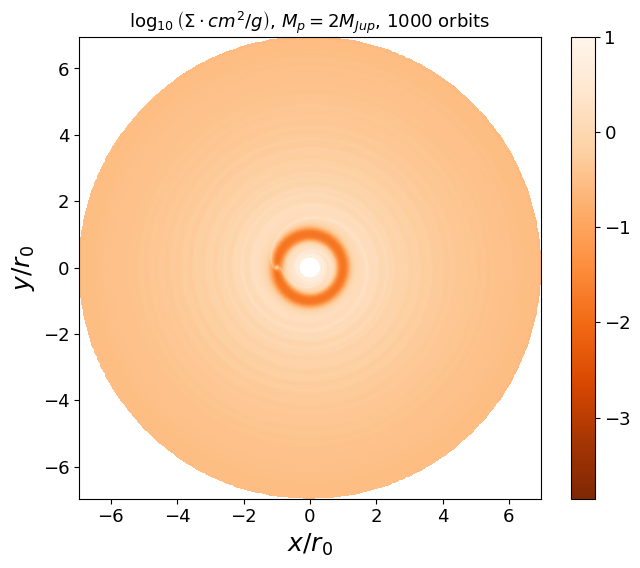

In [45]:
## make this a round plot so I know what's going on.
a=2
title=titles[a]
frame = frames[-1]

Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, phi, indexing='ij')

X = R*np.cos(PHI)
Y = R*np.sin(PHI)

plt.figure(figsize=(7.5,6))
#plt.subplot(1,2,1)
plt.pcolormesh(X, Y,np.log10(rho_cube[a][-1]),cmap=cm.Oranges_r, clim=(1,-3.5))
plt.title(f"$\\log_{{10}} \\left(\\Sigma\\cdot cm^2/g\\right)$, {title}, {(frames[-1])*10} orbits")
plt.colorbar()
plt.xlabel("$x/r_0$")
plt.ylabel("$y/r_0$")
plt.axis("scaled")

"""
plt.subplot(1,2,2)

plt.imshow(np.log10(rho_cube[0][-1]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (1,-3.5))
plt.title(f"{title}, $\\log_{{10}} \\left(\\Sigma \\cdot cm^2/g\\right)$, \n {(frame)*10} orbits")
plt.ylabel("$log10(r/r_0)$")
plt.xlabel("$\\varphi$")
plt.colorbar()
#plt.axis("scaled")

#plt.savefig("img/fargo_cartesian_fiducial.PNG")
"""
plt.savefig("img/fargo_no_ecc.PNG", bbox_inches="tight")